In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.4 MB/s eta 0:00:0000:01


In [2]:
import torch 
from torch import nn 
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision 
from torchvision import transforms, models
from torchinfo import summary
from torch.optim import Adam 

import os
import shutil 
from tqdm import tqdm
import matplotlib.pyplot as plt 
import cv2
from PIL import Image 
import random

from ultralytics import YOLO 
import numpy as np

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [4]:
new_name = "/kaggle/working/main_folder"
os.makedirs(new_name, exist_ok = True)

In [5]:
main_dir = "/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"
main_list = os.listdir(main_dir)
new_name = "/kaggle/working/main_folder"

for dir_ in tqdm(main_list):
    old_path = os.path.join(main_dir, dir_)
    dir_list = os.listdir(old_path)
    if len(dir_list) > 3:
        new_path = os.path.join(new_name, dir_)
        os.makedirs(new_path, exist_ok = True)
        
        old_path_list = os.listdir(old_path)
        
        for old_img in old_path_list:
            old_img_path = os.path.join(old_path, old_img)
            new_img_path = os.path.join(new_path, old_img)
            shutil.copy(old_img_path, new_img_path)

100%|██████████| 5749/5749 [01:00<00:00, 95.70it/s] 


In [7]:
detector = YOLO("//kaggle/input/yolo-faces-model/yolov12n-face.pt")
path = "/kaggle/working/main_folder/Aaron_Peirsol/Aaron_Peirsol_0002.jpg"

results = detector.predict(source=path, conf=0.3, save=False, verbose=False)[0]
print(f"Faces found: {len(results.boxes)}")

Faces found: 1


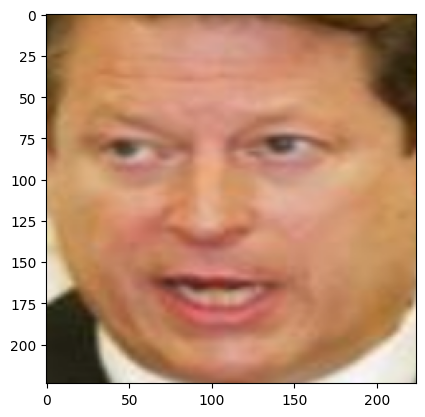

In [8]:
path = "/kaggle/working/main_folder/Al_Gore/Al_Gore_0004.jpg"

image = cv2.imread(path)
image_resized = cv2.resize(image, (640, 640))

results = detector(image_resized, conf=0.3, verbose=False)[0]

x1, y1, x2, y2, conf, cls = results.boxes.data[0].cpu().numpy().astype(int)

face = image_resized[y1:y2, x1:x2]
face = cv2.resize(face, (224, 224))
face = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)

plt.imshow(face)


In [98]:
def make_crop(img_path, detector, conf=0.3):
    img = cv2.imread(img_path)
    if img is None:
        print("Cannot read:", img_path)
        return None

    image_resized = cv2.resize(img, (640, 640))

    results = detector(image_resized, conf=conf, verbose=False)[0]

    if len(results) == 0:
        print(f"Empty file: {img_path}")
        return None 

    x1, y1, x2, y2, conf, cls = results.boxes.data[0].cpu().numpy().astype(int)

    face = image_resized[y1:y2, x1:x2]

    face = cv2.resize(face, (224, 224))
    face = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)

    return face

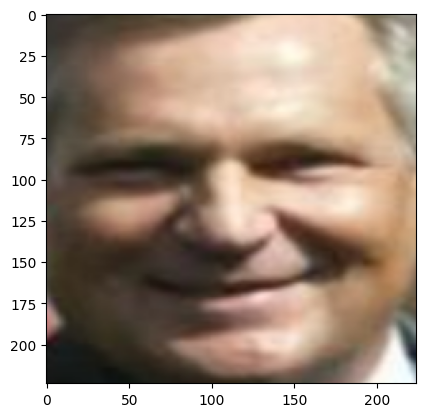

In [69]:
img_path = "/kaggle/working/main_folder/Aleksander_Kwasniewski/Aleksander_Kwasniewski_0001.jpg"
new_face = make_crop(img_path, detector)
plt.imshow(new_face)

In [11]:
name = "/kaggle/working/main_folder_cropped"
os.makedirs(name, exist_ok = True)

In [12]:
dir_name = "/kaggle/working/main_folder"
list_dir = os.listdir(dir_name)
new_dir_name = "/kaggle/working/main_folder_cropped"

for dir_ in tqdm(list_dir):
    new_dir_path = os.path.join(new_dir_name, dir_)
    os.makedirs(new_dir_path, exist_ok = True)
    dir_path = os.path.join(dir_name, dir_)
    for img in os.listdir(dir_path):
        full_img_path = os.path.join(dir_path, img)
        
        face_img = make_crop(full_img_path, detector)
    
        full_path = os.path.join(new_dir_path, img)

        if face_img is not None:
            cv2.imwrite(full_path, face_img)

100%|██████████| 610/610 [01:59<00:00,  5.11it/s]


In [13]:
os.path.isfile("/kaggle/working/main_folder/Lleyton_Hewitt/Lleyton_Hewitt_0003.jpg")

True

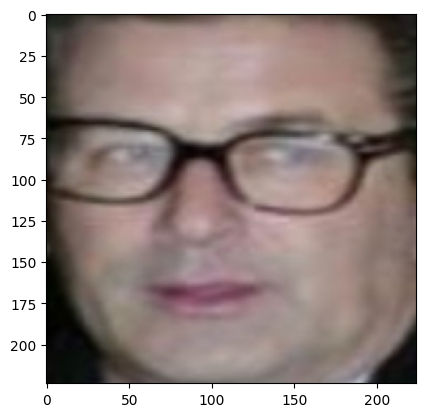

In [14]:
path = "/kaggle/working/main_folder_cropped/Alec_Baldwin/Alec_Baldwin_0003.jpg"
img = cv2.imread(path)
img = cv2.resize(img, (224, 224))
# img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
plt.imshow(img)

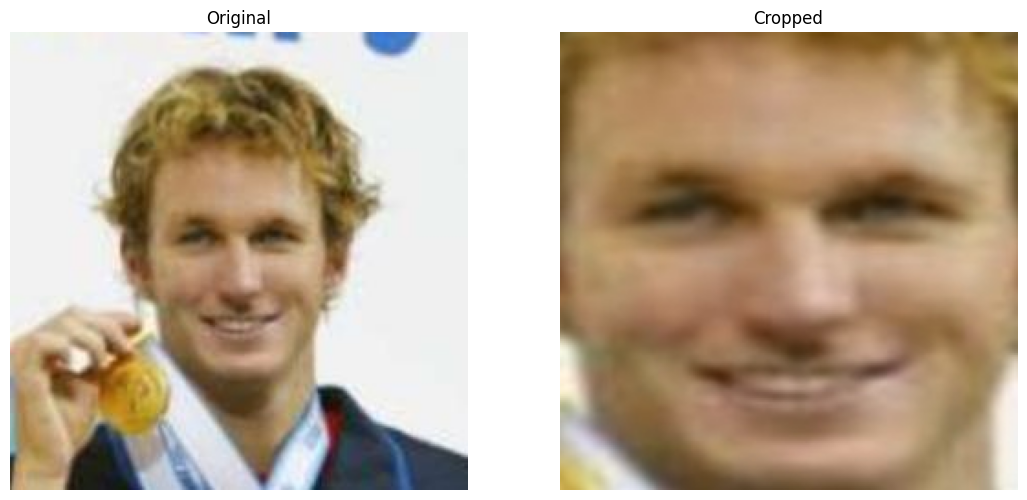

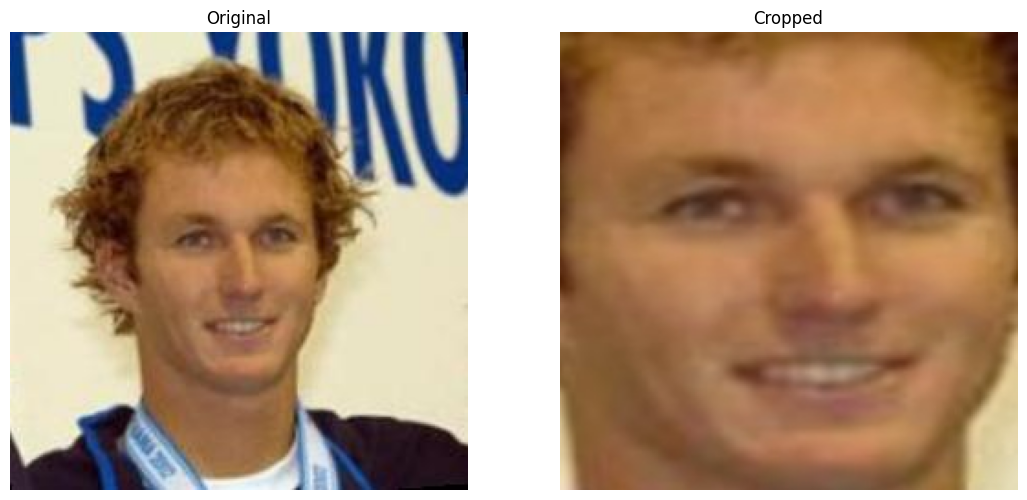

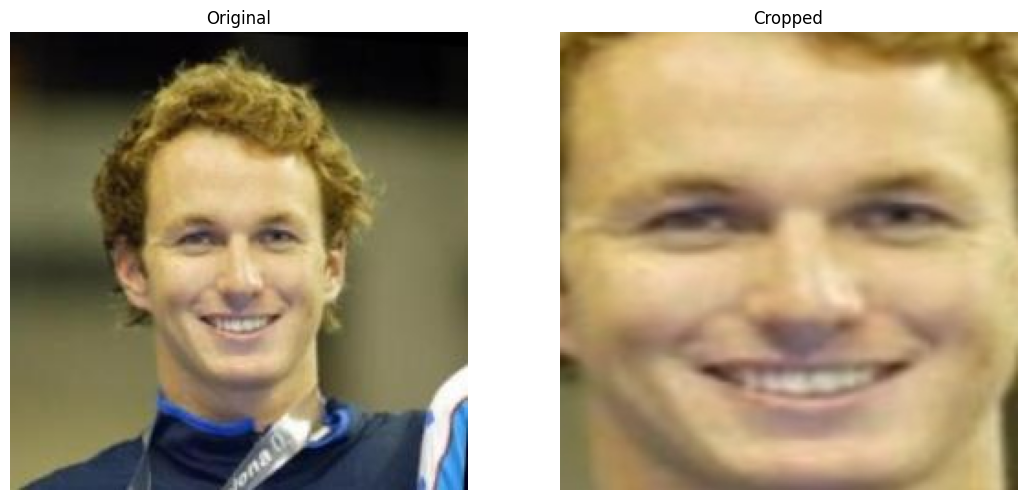

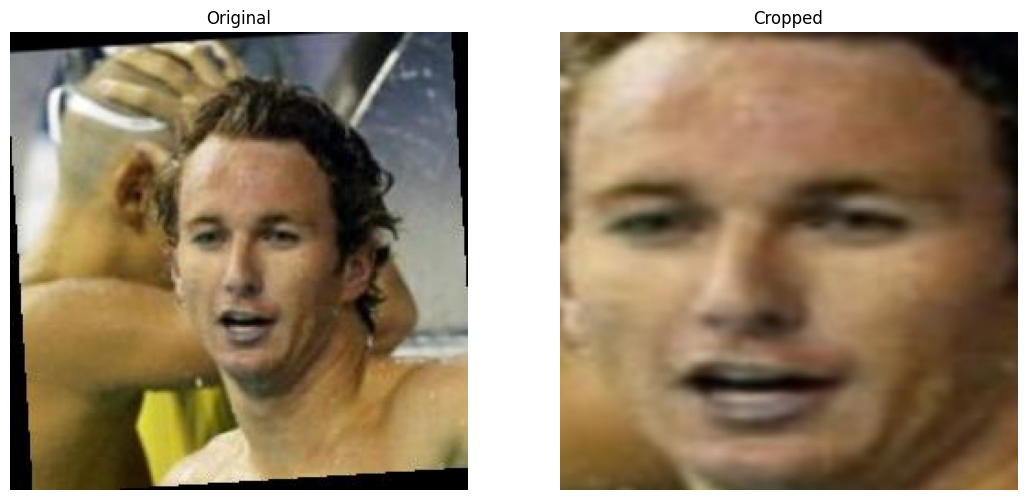

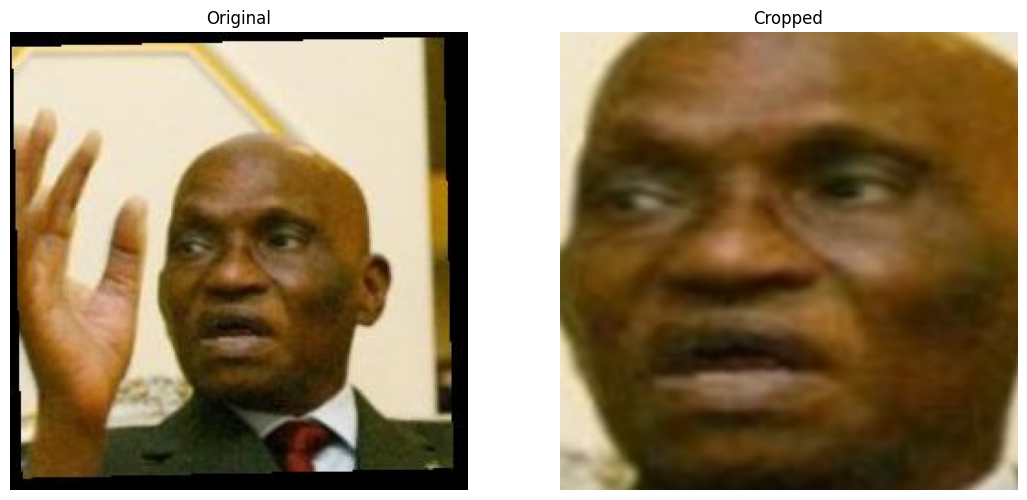

In [15]:
original_dir = "/kaggle/working/main_folder"
cropped_dir = "/kaggle/working/main_folder_cropped"

orig_folders = sorted(os.listdir(original_dir))
crop_folders = sorted(os.listdir(cropped_dir))

count = 0

for folder_idx, (orig_d, crop_d) in enumerate(zip(orig_folders, crop_folders)):
    full_orig_d_path = os.path.join(original_dir, orig_d)
    full_crop_d_path = os.path.join(cropped_dir, crop_d)

    orig_imgs = sorted(os.listdir(full_orig_d_path))
    crop_imgs = sorted(os.listdir(full_crop_d_path))

    for img_idx, (orig_img, crop_img) in enumerate(zip(orig_imgs, crop_imgs)):
        full_orig_img_path = os.path.join(full_orig_d_path, orig_img)
        full_crop_img_path = os.path.join(full_crop_d_path, crop_img)

        original_img = cv2.imread(full_orig_img_path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR)
        
        cropped_img = cv2.imread(full_crop_img_path)
    
        plt.figure(figsize=(13, 7))

        plt.subplot(1, 2, 1)
        plt.imshow(original_img)
        plt.title("Original")
        plt.axis("off")
        

        plt.subplot(1, 2, 2)
        plt.imshow(cropped_img)
        plt.title("Cropped")
        plt.axis("off")

        plt.show()
        
        count +=1

        if count == 5:
            break
            
    if count == 5:
        break
        


In [16]:
folder = "/kaggle/working/main_folder_cropped"
dir_path = sorted(os.listdir(folder))
dir_path[:3]

['Aaron_Peirsol', 'Abdoulaye_Wade', 'Abdullah']

In [17]:
def split_classes(root_dir, val_ratio=0.2):
    classes = sorted(os.listdir(root_dir))
    random.shuffle(classes)

    val_count = int(len(classes) * val_ratio)

    train_classes = classes[val_count:]
    val_classes = classes[:val_count]

    return train_classes, val_classes
    

In [18]:
root_dir = "/kaggle/working/main_folder_cropped"
train_classes, val_classes = split_classes(root_dir, val_ratio=0.2)
len(train_classes), len(val_classes)

(488, 122)

In [19]:
train_classes[:2], val_classes[:2]

(['Paula_Radcliffe', 'Tung_Chee-hwa'], ['Gordon_Brown', 'Ciro_Gomes'])

In [20]:
class CustomDataset(Dataset):
    def __init__(self, root_dir, folders, transform=None):
        self.root_dir = root_dir
        self.folders = folders
        self.transform = transform
    
        self.images = []
        self.labels = []

        for i, folder in enumerate(self.folders):
            full_folder_path = os.path.join(self.root_dir, folder)
            for img in os.listdir(full_folder_path):
                full_img_path = os.path.join(full_folder_path, img)
                self.images.append(full_img_path)
                self.labels.append(i)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]

        img = Image.open(img).convert("RGB")

        if self.transform:
            img = self.transform(img)       

        return img, label
        

In [22]:
train_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                    
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [23]:
root_dir = "/kaggle/working/main_folder_cropped"
train_data = CustomDataset(root_dir, train_classes, train_transformer)
val_data = CustomDataset(root_dir, val_classes, val_transformer)

In [24]:
len(train_data), len(val_data)

(5591, 1142)

In [25]:
train_data[12]

(tensor([[[ 1.0844,  1.2728,  1.4440,  ..., -0.7993, -0.9705, -1.1418],
          [ 1.2557,  1.4269,  1.5639,  ..., -0.6965, -0.8507, -1.0219],
          [ 1.4440,  1.5982,  1.6838,  ..., -0.5596, -0.7137, -0.8849],
          ...,
          [-1.1418, -1.0904, -1.0562,  ..., -1.2788, -1.2617, -1.2617],
          [-1.1589, -1.1247, -1.0562,  ..., -1.2788, -1.2788, -1.2788],
          [-1.1760, -1.1418, -1.0733,  ..., -1.2617, -1.2788, -1.2788]],
 
         [[ 1.4832,  1.6758,  1.8683,  ..., -0.2850, -0.5301, -0.7052],
          [ 1.6583,  1.8333,  1.9909,  ..., -0.1800, -0.4076, -0.5826],
          [ 1.8508,  2.0259,  2.1134,  ..., -0.0399, -0.2675, -0.4251],
          ...,
          [-0.7577, -0.7052, -0.6702,  ..., -0.9328, -0.9328, -0.9328],
          [-0.7402, -0.7052, -0.6527,  ..., -0.9678, -0.9503, -0.9503],
          [-0.7577, -0.7227, -0.6702,  ..., -0.9328, -0.9503, -0.9503]],
 
         [[ 2.1694,  2.3437,  2.4483,  ..., -0.1661, -0.3753, -0.5844],
          [ 2.3437,  2.5006,

In [26]:
val_data[0]

(tensor([[[-1.5357, -1.5014, -1.4500,  ..., -0.8849, -0.8678, -0.8335],
          [-1.5870, -1.5528, -1.5185,  ..., -0.7650, -0.7479, -0.7308],
          [-1.6555, -1.6384, -1.6213,  ..., -0.6281, -0.5938, -0.5767],
          ...,
          [-2.0152, -2.0152, -2.0152,  ..., -1.3130, -1.3302, -1.3302],
          [-2.0152, -2.0152, -2.0152,  ..., -1.2788, -1.2959, -1.2959],
          [-1.9980, -1.9980, -1.9980,  ..., -1.2959, -1.2959, -1.2959]],
 
         [[-1.2654, -1.2304, -1.2129,  ..., -0.6527, -0.6352, -0.6001],
          [-1.3179, -1.2829, -1.2829,  ..., -0.5301, -0.5126, -0.4951],
          [-1.3880, -1.3704, -1.3529,  ..., -0.4251, -0.3901, -0.3725],
          ...,
          [-2.0007, -2.0007, -2.0007,  ..., -1.4930, -1.5105, -1.5105],
          [-2.0007, -2.0007, -2.0007,  ..., -1.4930, -1.5105, -1.5105],
          [-1.9832, -1.9832, -1.9832,  ..., -1.5105, -1.5105, -1.5105]],
 
         [[-1.0201, -0.9853, -0.9330,  ..., -0.3230, -0.3055, -0.2707],
          [-1.0724, -1.0376,

In [27]:
train_data.labels[:26]

[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

In [28]:
class_indicies = {}
for idx, label in enumerate(train_data.labels):
    if label not in class_indicies:
        class_indicies[label] = []
    class_indicies[label].append(idx)

class_indicies[1], class_indicies[2]

([6, 7, 8, 9, 10, 11, 12, 13, 14],
 [15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39])

In [29]:
label = train_data.labels[60] 
print(label)
print(class_indicies[label])
# this will return 2 random indicies from class_indicies[label] list 
random.sample(class_indicies[label], 2)

6
[55, 56, 57, 58, 59, 60]


[55, 59]

In [30]:
class TripletDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.class_indicies = {}

        for idx, label in enumerate(self.dataset.labels):
            if label not in self.class_indicies:
                self.class_indicies[label] = []
            self.class_indicies[label].append(idx)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        anchor_label = self.dataset.labels[idx]

        positive_idx, anchor_idx = random.sample(self.class_indicies[anchor_label], 2)
        positive_img = self.dataset[positive_idx][0]
        anchor_img = self.dataset[anchor_idx][0]

        negative_label = random.choice([label for label in self.class_indicies.keys() if label != anchor_label])
        negative_idx = random.choice(self.class_indicies[negative_label])
        negative_img = self.dataset[negative_idx][0]

        return anchor_img, positive_img, negative_img
        

In [31]:
train_triplet_data = TripletDataset(train_data)
val_triplet_data = TripletDataset(val_data)

In [32]:
x, y, z = train_triplet_data[0]
x.shape, y.shape, z.shape

(torch.Size([3, 224, 224]),
 torch.Size([3, 224, 224]),
 torch.Size([3, 224, 224]))

In [36]:
def output(data, limit):
    for i, (x, y, z) in enumerate(data):
        x = x.permute(1, 2, 0).cpu().numpy()
        x = (x + 1) / 2
        x = np.clip(x, 0, 1)
        x = (x * 255).astype(np.uint8)
        x = cv2.cvtColor(x, cv2.COLOR_RGB2BGR)
        
        y = y.permute(1, 2, 0).cpu().numpy()
        y = (y + 1) / 2
        y = np.clip(y, 0, 1)
        y = (y * 255).astype(np.uint8)
        y = cv2.cvtColor(y, cv2.COLOR_RGB2BGR)
        
        z = z.permute(1, 2, 0).cpu().numpy()
        z = (z + 1) / 2
        z = np.clip(z, 0, 1)
        z = (z * 255).astype(np.uint8)
        z = cv2.cvtColor(z, cv2.COLOR_RGB2BGR)

        plt.figure(figsize=(13, 8))
    
        plt.subplot(1, 3, 1)
        plt.imshow(x)
        plt.axis("off")
        plt.title("Anchor")
    
        plt.subplot(1, 3, 2)
        plt.imshow(y)
        plt.axis("off")
        plt.title("Positive")
    
        plt.subplot(1, 3, 3)
        plt.imshow(z)
        plt.axis("off")
        plt.title("Negative")
        
        plt.show()
    
        if i+1 == limit:
            break

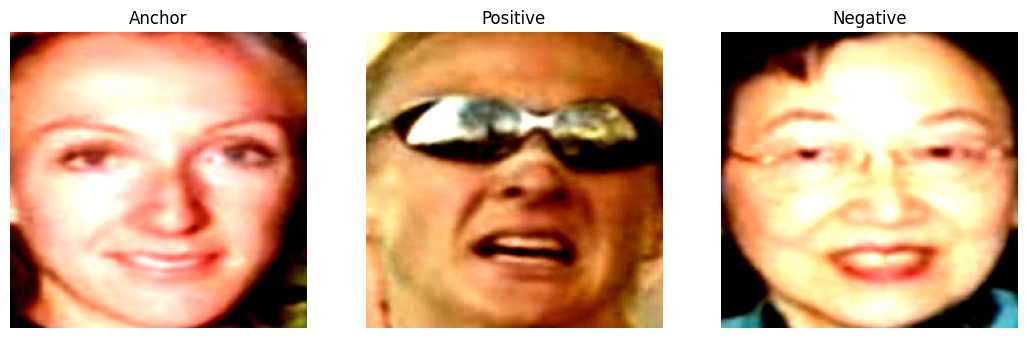

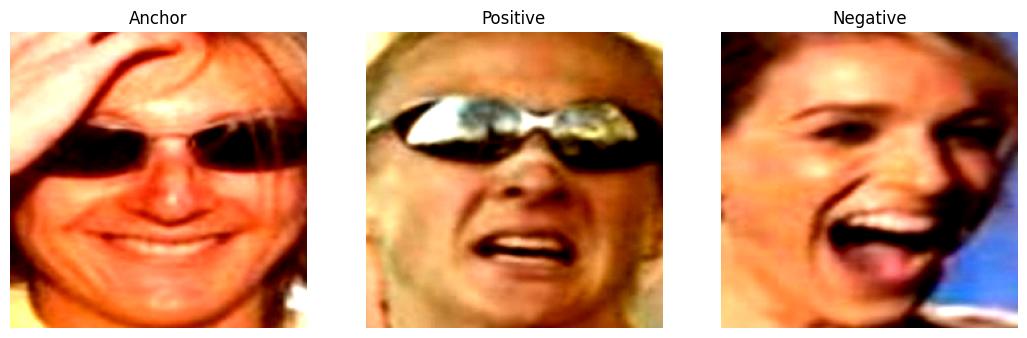

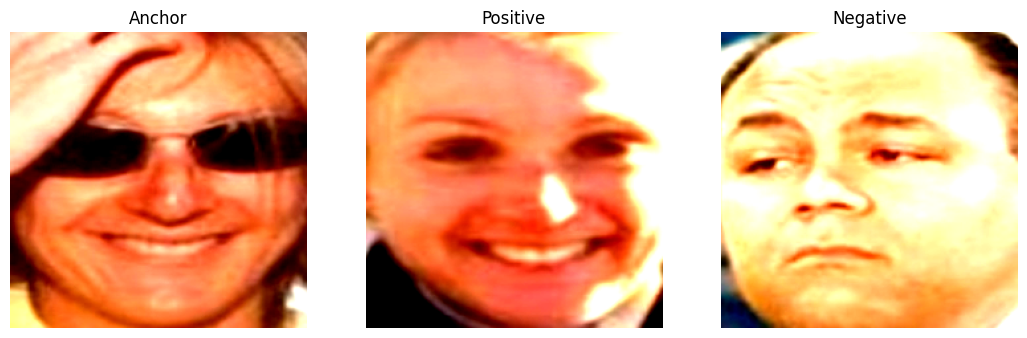

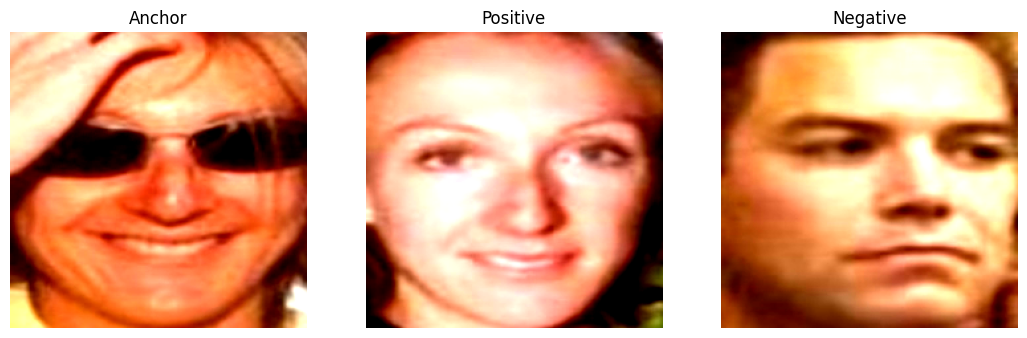

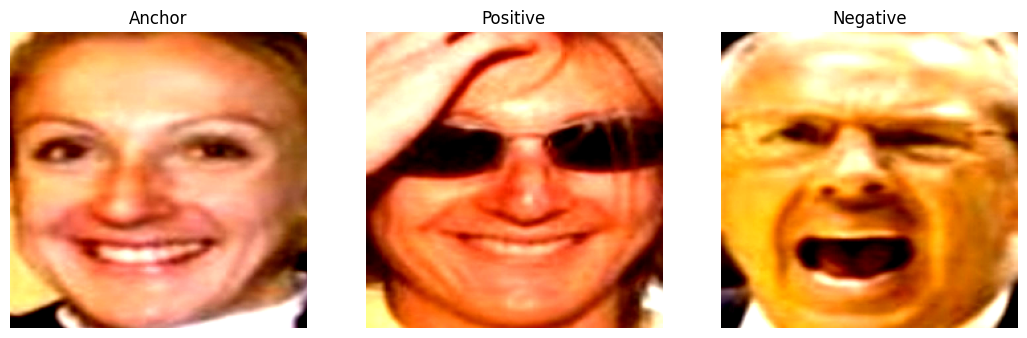

In [37]:
output(train_triplet_data, 5)

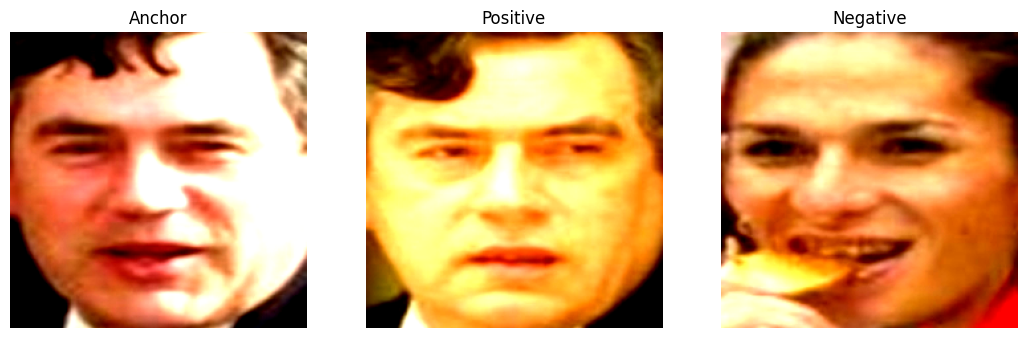

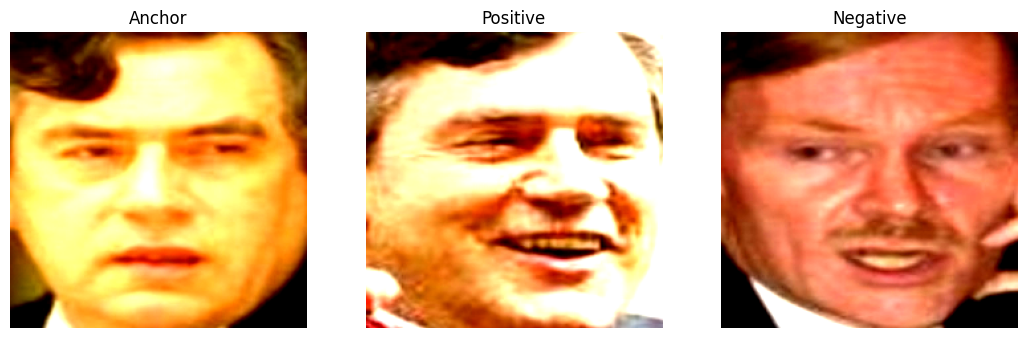

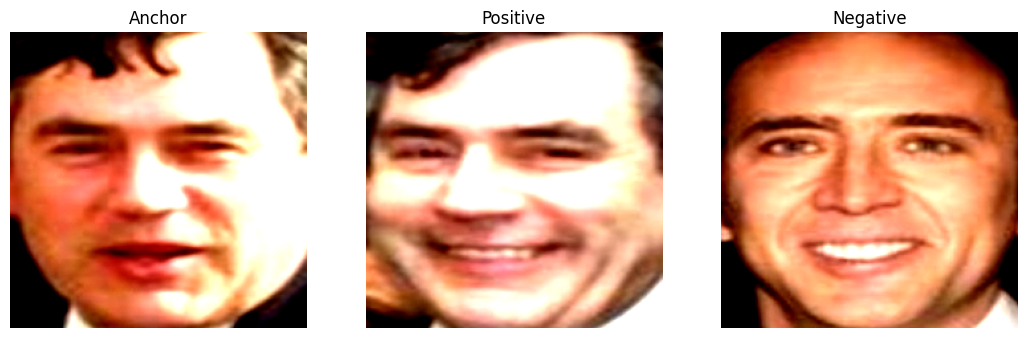

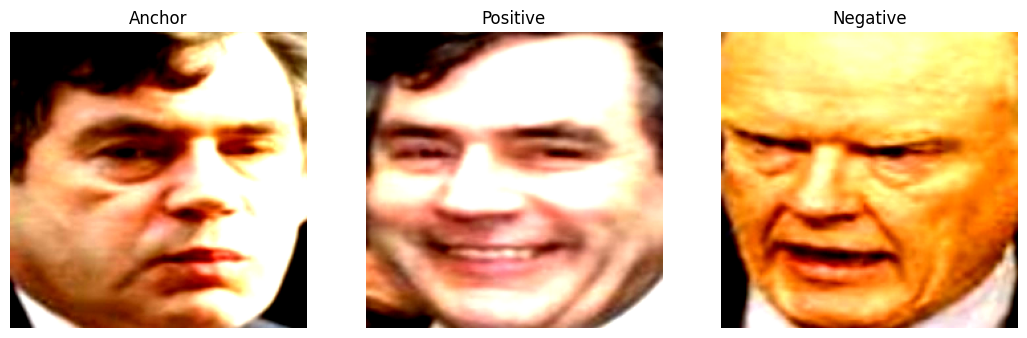

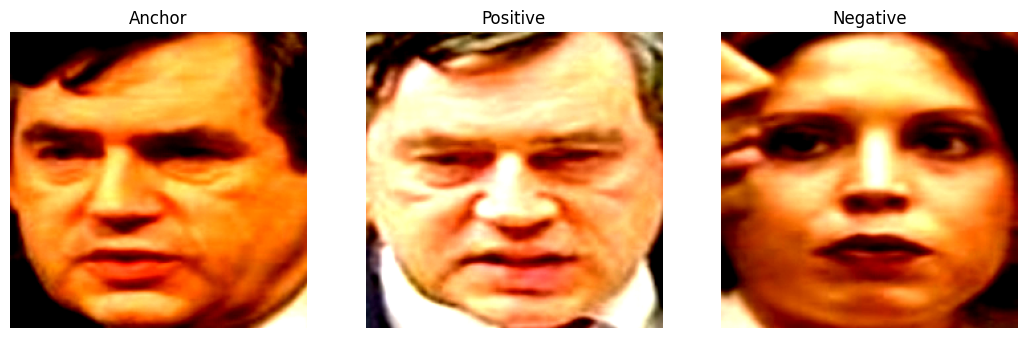

In [38]:
output(val_triplet_data, 5)

In [39]:
batch_size = 64

train_dl = DataLoader(train_triplet_data, batch_size=batch_size, shuffle=True, num_workers=4)
val_dl = DataLoader(val_triplet_data, batch_size=batch_size, shuffle=True, num_workers=4)

In [41]:
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def calc_eucledean(self, x1, x2):
        return (x1 - x2).pow(2).sum(1)

    def forward(self, anchor, positive, negative):
        dist_positive = self.calc_eucledean(anchor, positive)
        dist_negative = self.calc_eucledean(anchor, negative)
        loss = torch.relu(dist_positive - dist_negative + self.margin)

        return loss.mean()

In [42]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        body = models.resnet18(weights="DEFAULT")
        self.backbone = nn.Sequential(*list(body.children())[:-1])
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.BatchNorm1d(512)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.head(x)
        x = F.normalize(x, dim=1)
        return x

    def predict(self, x):
        self.eval()

        with torch.no_grad():
            x = self.forward(x)
        return x

In [43]:
model = Net()
tensor = torch.randn(1, 3, 224, 224)
out = model(tensor)
out.shape

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 179MB/s]


torch.Size([1, 512, 1, 1])

In [44]:
summary(model, input_data=torch.randn(1, 3, 224, 224))

Layer (type:depth-idx)                        Output Shape              Param #
Net                                           [1, 512, 1, 1]            --
├─Sequential: 1-1                             [1, 512, 1, 1]            --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
│    └─Sequential: 2-5                        [1, 64, 56, 56]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 56, 56]           73,984
│    │    └─BasicBlock: 3-2                   [1, 64, 56, 56]           73,984
│    └─Sequential: 2-6                        [1, 128, 28, 28]          --
│    │    └─BasicBlock: 3-3                   [1, 128, 28, 28]          230,144
│    │    └─BasicBlock: 3-4                   [1, 128, 28, 28]          295,42

In [45]:
model.to(device)

Net(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  

In [47]:
def train(model, train_dl, val_dl, loss_fn, optimizer, epochs, device):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        for x, y, z in tqdm(train_dl):
            x = x.to(device)
            y = y.to(device)
            z = z.to(device)

            optimizer.zero_grad()

            x_emb = model(x)
            y_emb = model(y)
            z_emb = model(z)

            if len(x_emb.shape) != 2 or len(y_emb.shape) != 2 or len(z_emb.shape) !=2:
                x_emb = x_emb.squeeze(2, 3)
                y_emb = y_emb.squeeze(2, 3)
                z_emb = z_emb.squeeze(2, 3)
                

            loss = loss_fn(x_emb, y_emb, z_emb)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()


        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y, z in tqdm(val_dl):
                x = x.to(device)
                y = y.to(device)
                z = z.to(device)

                x_emb = model(x)
                y_emb = model(y)
                z_emb = model(z)

                if len(x_emb.shape) != 2 or len(y_emb.shape) != 2 or len(z_emb.shape) !=2:
                    x_emb = x_emb.squeeze(2, 3)
                    y_emb = y_emb.squeeze(2, 3)
                    z_emb = z_emb.squeeze(2, 3)
        
                loss = loss_fn(x_emb, y_emb, z_emb)
                val_loss += loss.item()

        total_train_loss = train_loss / len(train_dl)
        total_val_loss = val_loss / len(val_dl)

        history["train_loss"].append(total_train_loss)
        history["val_loss"].append(total_val_loss)
        
        print(f"Epoch: {epoch+1} | train_loss: {total_train_loss:.4f}  | val_loss: {total_val_loss:.4f}")
            
    return history 
                

        

In [48]:
loss_fn = TripletLoss()
optimizer = Adam(model.parameters(), lr=1e-3)
epochs = 10

In [49]:
history = train(model, train_dl, val_dl, loss_fn, optimizer, epochs, device)

100%|██████████| 18/18 [00:04<00:00,  4.30it/s]


Epoch: 1 | train_loss: 2.8275  | val_loss: 0.3698


100%|██████████| 18/18 [00:03<00:00,  4.67it/s]


Epoch: 2 | train_loss: 0.2677  | val_loss: 0.3237


100%|██████████| 18/18 [00:04<00:00,  4.36it/s]


...

Epoch: 8 | train_loss: 0.1034  | val_loss: 0.2667


100%|██████████| 18/18 [00:04<00:00,  4.46it/s]


Epoch: 9 | train_loss: 0.0891  | val_loss: 0.2281


100%|██████████| 18/18 [00:03<00:00,  4.72it/s]

Epoch: 10 | train_loss: 0.0829  | val_loss: 0.2090


In [50]:
def output_metric(history, name):
    plt.plot(history[f"train_{name}"], label="training set")
    plt.plot(history[f"val_{name}"], label="validation set")
    plt.ylabel(f"{name}")
    plt.xlabel("Epochs")
    plt.show()

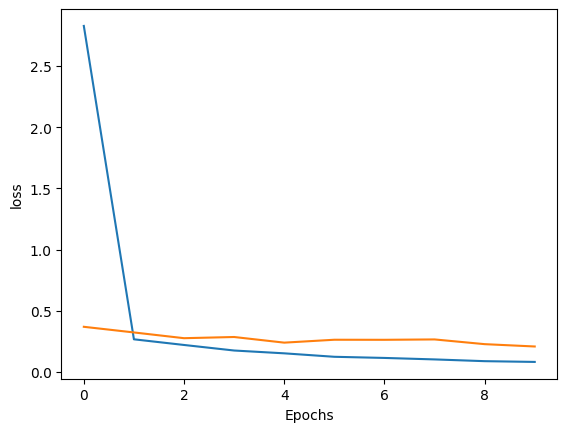

In [51]:
output_metric(history, "loss")

In [135]:
torch.save(model.state_dict(), "triplet_model.pt")

In [52]:
def upload_img(path):
    img = Image.open(path).convert("RGB")
    transformer = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    image = transformer(img)
    return image.unsqueeze(0)

In [53]:
path = "/kaggle/working/main_folder_cropped/Aaron_Peirsol/Aaron_Peirsol_0001.jpg"
img = upload_img(path)
img.shape

torch.Size([1, 3, 224, 224])

In [54]:
def compute_dist(path_1, path_2, model, device):

    img_1 = upload_img(path_1)
    img_2 = upload_img(path_2)

    img_1 = img_1.to(device)
    img_2 = img_2.to(device)

    model.eval()
    with torch.no_grad():
        vector_1 = model(img_1)
        vector_2 = model(img_2)

    dist = torch.norm(vector_1 - vector_2)

    return dist.item()

Difference: 1.6705


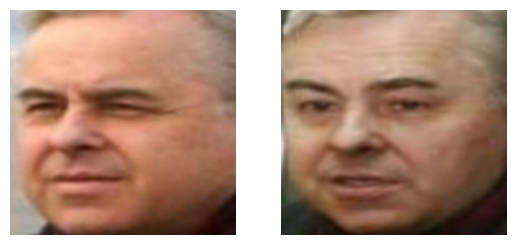

In [62]:
path_1 = "/kaggle/working/main_folder_cropped/Alexander_Losyukov/Alexander_Losyukov_0001.jpg"
path_2 = "/kaggle/working/main_folder_cropped/Alexander_Losyukov/Alexander_Losyukov_0002.jpg"

img_1 = cv2.imread(path_1)
img_2 = cv2.imread(path_2)



dist = compute_dist(path_1, path_2, model, device)
print(f"Difference: {dist:.4f}")

plt.subplot(1, 2, 1)
plt.imshow(img_1)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_2)
plt.axis("off")

plt.show()



Difference: 2.5288


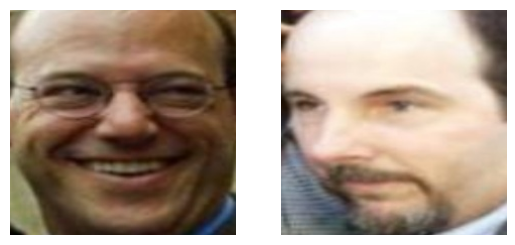

In [56]:
path_1 = "/kaggle/working/main_folder_cropped/Ari_Fleischer/Ari_Fleischer_0001.jpg"
path_2 = "/kaggle/working/main_folder_cropped/Arminio_Fraga/Arminio_Fraga_0002.jpg"

img_1 = cv2.imread(path_1)
img_2 = cv2.imread(path_2)

dist = compute_dist(path_1, path_2, model, device)
print(f"Difference: {dist:.4f}")

plt.subplot(1, 2, 1)
plt.imshow(img_1)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_2)
plt.axis("off")

plt.show()



In [119]:
def make_crop(path, detector, conf=0.3):
    img = cv2.imread(path)
    img_resized = cv2.resize(img, (640, 640))

    results = detector(img_resized, conf=conf, verbose=False)[0]
    result = results.boxes.data.tolist()[0]

    result = map(int, result)
    x1, y1, x2, y2, _, _ = result

    face = img_resized[y1:y2, x1:x2]

    face = cv2.resize(face, (224, 224))
    face = cv2.cvtColor(face, cv2.COLOR_RGB2BGR)

    return face

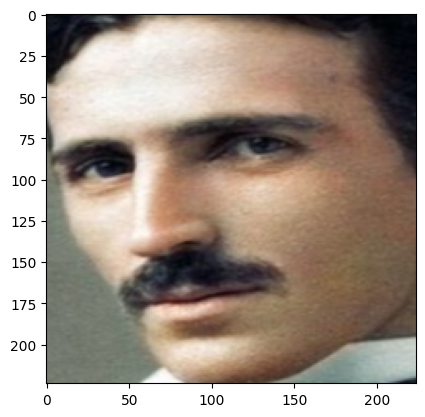

In [120]:
path = "/kaggle/input/test-faces-folder/faces/3.jpg"
face = make_crop(path, detector)
plt.imshow(face)

In [126]:
transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

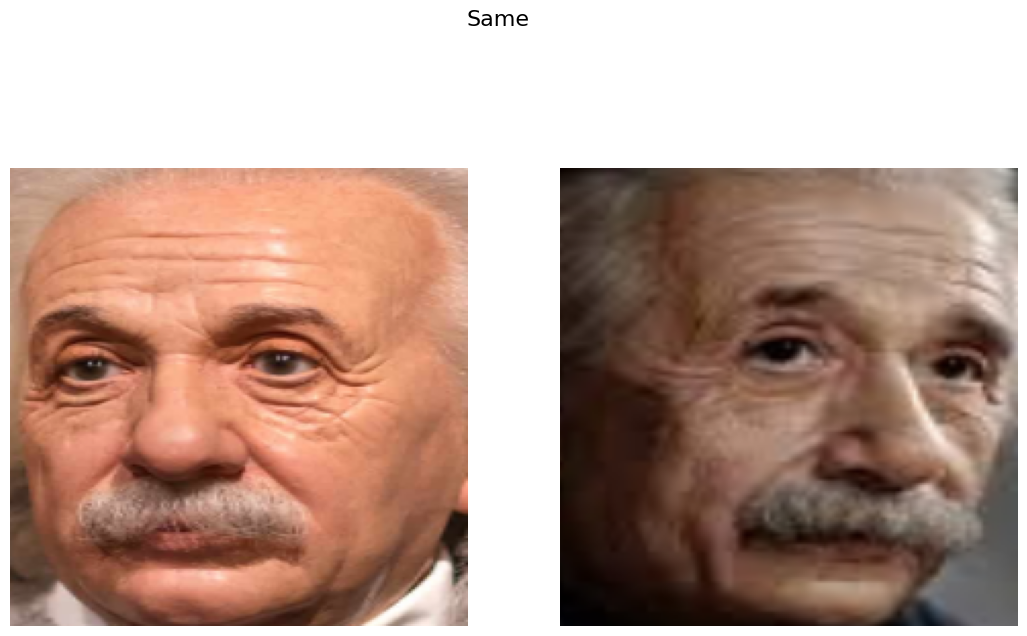

In [134]:
def test(path1, path2, detector, model, transformer, device, threshold=2.0):

    model.to(device)
    photo_1 = make_crop(path1, detector)
    photo_2 = make_crop(path2, detector)

    photo_1_ = Image.fromarray(photo_1)
    photo_2_ = Image.fromarray(photo_2)

    tensor_1 = transformer(photo_1_).unsqueeze(0).to(device)
    tensor_2 = transformer(photo_2_).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        vector_1 = model(tensor_1)
        vector_2 = model(tensor_2)

    vector_1 = F.normalize(vector_1, dim=1)
    vector_2 = F.normalize(vector_2, dim=1)

    dist = torch.norm(vector_1 - vector_2)

    res = "Same" if dist.item() <= threshold else "Different" 

    plt.figure(figsize=(13, 8))
    plt.suptitle(f"{res}:{dist}", fontsize=16)

    plt.subplot(1, 2, 1)
    plt.imshow(photo_1)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(photo_2)
    plt.axis("off")

    plt.show()

    return res
